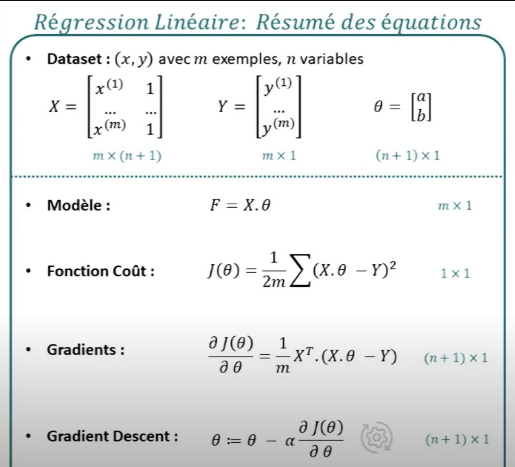

import numpy as np
import matplotlib.pyplot

In [130]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Dataset

In [131]:
data=pd.read_csv('diametre_price.csv')
data.isnull().sum()

diametre    0
price       0
dtype: int64

In [132]:
data.describe()

,diametre,price
count,100.000000,100.000000
mean,33.890106,57.344645
std,10.519351,19.325137
min,15.170136,5.926383
25%,25.017269,41.062016
50%,35.160642,58.015393
75%,42.984341,72.268536
max,49.907666,93.907842


<Axes: ylabel='diametre'>

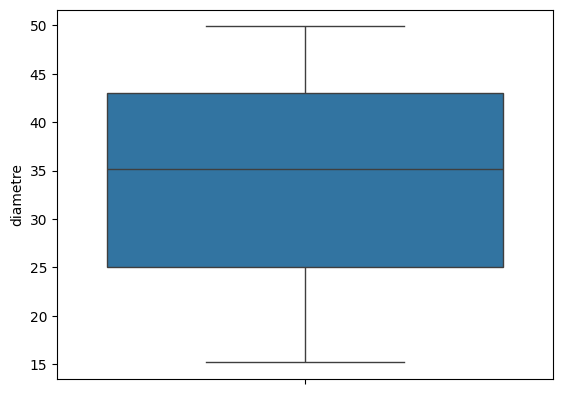

In [189]:
# Visualisation plusieures features, les valeurs extremes sont a traiter
sns.boxplot(data['diametre'])


<Axes: ylabel='price'>

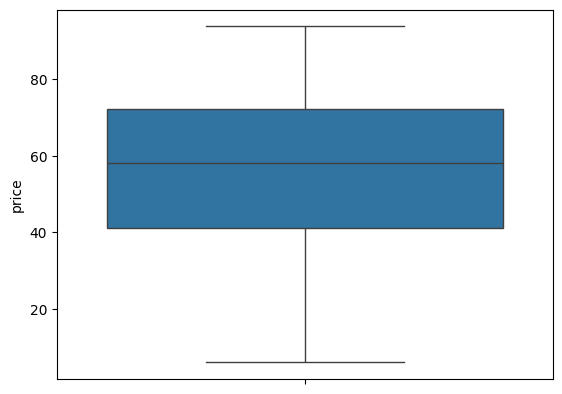

In [190]:
sns.boxplot(data['price'])

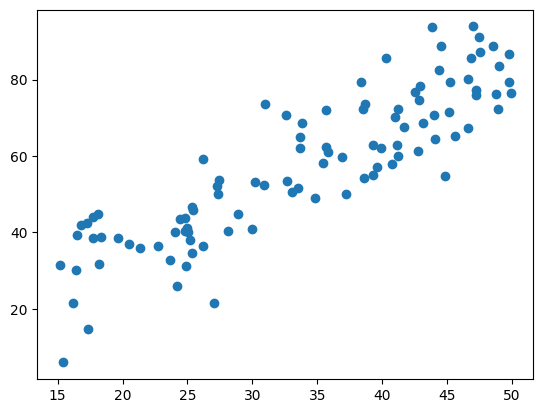

In [191]:
# price en fonction du diametre
plt.scatter(data['diametre'],data['price'])

# Modele

In [170]:
def model(X,theta):
    return X.dot(theta)

# Fonction Cout

In [171]:
def loss_function(X,theta,y):
    m=len(y)
    y_pred=model(X,theta)
    return (1/(m))*np.sum((y_pred-y)**2)

# Gradient

In [172]:
def gradient(X,theta,y):
    m=len(y)
    y_pred=model(X,theta)
    return (1/m)*X.T.dot(y_pred-y)

# Gradient descent

In [173]:
def mise_a_jour(X,theta,y,learning_rate):
    return theta - learning_rate*gradient(X,theta,y)

# Regression linear

In [174]:
def linear_regression(X,y,theta,learning_rate=0.001,iterations=1000):
    loss=[]
    for _ in range(iterations):
        loss.append(loss_function(X,theta,y))
        theta=mise_a_jour(X,theta,y,learning_rate)
        print(theta)
    return theta,loss

# Prediction

In [193]:
def predict(X,theta):
    X=np.c_[X,np.ones(X.shape[0])]
    return model(X,theta)

# intitialisation du param

In [197]:
# Attention a learning rate et theta pendant l'entrainement 
# Sinon loss vas faire n'importe quoi 0.01 est trop grand
# 0.001 est bien
X=data['diametre'].to_numpy().reshape(-1,1)
X=np.c_[X,np.ones(X.shape[0])] # ajout de la colonne de biais
y=data['price'].to_numpy().reshape(-1,1)
theta=np.zeros((X.shape[1],1))+0.2
X.shape,y.shape,theta.shape

((100, 2), (100, 1), (2, 1))

# Avant Training

Text(0, 0.5, 'Prix')

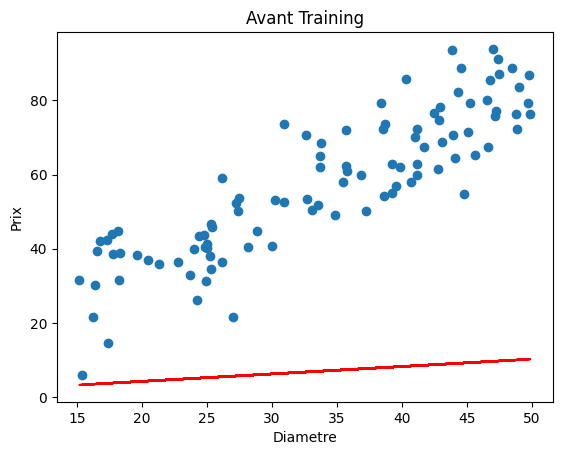

In [198]:
y_pred=predict(data['diametre'],theta)
plt.scatter(data['diametre'],data['price'])
plt.plot(data['diametre'],y_pred,color='red')
plt.title('Avant Training')
plt.xlabel('Diametre')
plt.ylabel('Prix')

# Training

[[2.06179462]
 [0.25036662]]
[[1.57957819]
 [0.23758647]]
[[1.70446627]
 [0.24116145]]
[[1.67211282]
 [0.24050039]]
[[1.68048531]
 [0.24093646]]
[[1.67830968]
 [0.24108834]]
[[1.67886604]
 [0.24131381]]
[[1.67871481]
 [0.24152019]]
[[1.67874684]
 [0.24173149]]
[[1.67873141]
 [0.2419415 ]]
[[1.67872828]
 [0.24215182]]
[[1.67872196]
 [0.24236203]]
[[1.67871647]
 [0.24257225]]
[[1.67871076]
 [0.24278245]]
[[1.67870511]
 [0.24299263]]
[[1.67869944]
 [0.24320278]]
[[1.67869378]
 [0.24341293]]
[[1.67868812]
 [0.24362305]]
[[1.67868246]
 [0.24383315]]
[[1.6786768 ]
 [0.24404324]]
[[1.67867114]
 [0.24425331]]
[[1.67866549]
 [0.24446336]]
[[1.67865983]
 [0.24467339]]
[[1.67865417]
 [0.2448834 ]]
[[1.67864851]
 [0.24509339]]
[[1.67864286]
 [0.24530337]]
[[1.6786372 ]
 [0.24551333]]
[[1.67863154]
 [0.24572327]]
[[1.67862589]
 [0.24593319]]
[[1.67862023]
 [0.24614309]]
[[1.67861458]
 [0.24635298]]
[[1.67860893]
 [0.24656285]]
[[1.67860327]
 [0.24677269]]
[[1.67859762]
 [0.24698252]]
[[1.67859197]


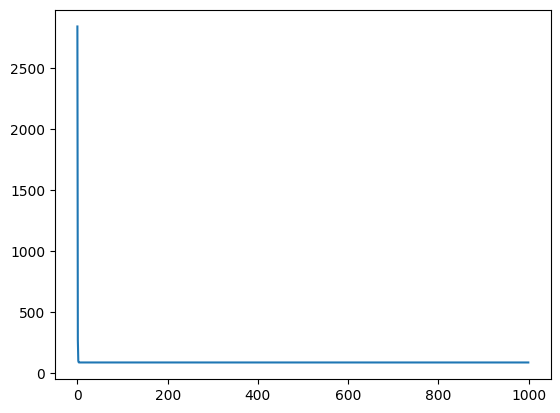

In [199]:
theta,loss=linear_regression(X,y,theta,learning_rate=0.001,iterations=1000)
plt.plot(loss)

# Apres Training

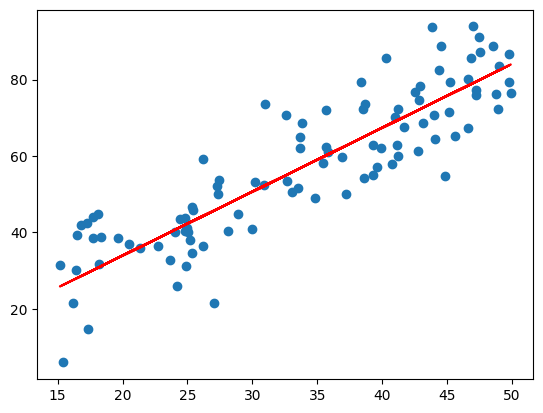

In [203]:
y_pred=model(X,theta)
plt.scatter(data['diametre'],data['price'])
plt.plot(data['diametre'],y_pred,color='red')

In [201]:
theta

array([[1.6733605 ],
       [0.44138471]])

In [202]:
print("Le prix d'un diamant de 0.5 cm de diametre est de : ",predict(np.array([[75.5]]),theta))

Le prix d'un diamant de 0.5 cm de diametre est de :  [[126.78010239]]
